## 03 — REGRESSOR RN MLP: VALIDAÇÃO CRUZADA
**Objetivo**: avaliar por validação cruzada a rede neural *Multilayer Perceptron* (`MLPRegressor`) com três **hiperparametrizações** (U, E, O), estimando a **sobr** a partir das 10 **features de entrada**, e escolher o **melhor modelo** pelo critério da spec.

* **U**: subajustada (*underfitted*)
* **E**: equilibrada
* **O**: sobreajustada (*overfitted*)

**Saídas**
* `results/rn.json`: as três hiperparametrizações (tabela 4), os MSE de treino e de validação por fold, médias, dpa e média das difs (tabela 5), e o rótulo do melhor modelo

O dataset de teste cego **não** é lido neste notebook (só no `04_teste_cego.ipynb`).

**(1) Leitura do dataset de treino/validação**

Lemos as 10.000 vítimas geradas pelo `01_dataset.ipynb`. X recebe somente as 10 features de entrada; gcs, avpu e tri são **features proibidas** e sobr é o alvo, então nenhuma delas pode estar em X.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Caminhos
DATASET_CSV = Path("datasets/vict/10000v/data.csv")
RESULTS_JSON = Path("results/rn.json")
RESULTS_JSON.parent.mkdir(parents=True, exist_ok=True)

FEATURES_ENTRADA = ['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
FEATURES_PROIBIDAS = ['gcs', 'avpu', 'tri', 'sobr']  # sobr é o alvo
ALVO = 'sobr'

df = pd.read_csv(DATASET_CSV)
assert len(df) == 10000, f"esperado 10000 vítimas, obtido {len(df)}"

X = df[FEATURES_ENTRADA]
y = df[ALVO]

# Nenhuma feature proibida (nem o alvo) pode entrar em X
assert not set(FEATURES_PROIBIDAS) & set(X.columns), f"feature proibida em X: {set(FEATURES_PROIBIDAS) & set(X.columns)}"
assert list(X.columns) == FEATURES_ENTRADA

print(f"Arquivo.....:\t{DATASET_CSV}")
print(f"Vítimas.....:\t{len(X):>6}")
print(f"Features (X):\t{list(X.columns)}")
print(f"Alvo (y)....:\t{ALVO}  [{y.min():.4f}, {y.max():.4f}]")

Arquivo.....:	datasets/vict/10000v/data.csv
Vítimas.....:	 10000
Features (X):	['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']
Alvo (y)....:	sobr  [0.0500, 1.0000]


**(2) Métricas: MSE, dpa e média das difs**

* **MSE de fold**: média dos erros quadráticos, **sem raiz** (ADR 0001). O `cross_validate` devolve o MSE negativo (`neg_mean_squared_error`), então trocamos o sinal.
* **dpa**: desvio padrão amostral dos valores por fold, com divisor k−1 (`ddof=1`).
* **Média das difs**: média sobre os folds de |MSE de treino − MSE de validação|.

Antes de usar o dpa, conferimos que ele reproduz o exemplo do enunciado: folds [0.0232, 0.0011, 0.0198] → dpa 0,0119.

In [2]:
def dpa(valores):
    # Desvio padrão amostral (divisor k-1)
    return float(np.std(valores, ddof=1))

# Exemplo numérico do enunciado
dpa_exemplo = dpa([0.0232, 0.0011, 0.0198])
assert round(dpa_exemplo, 4) == 0.0119, f"dpa do exemplo deveria ser 0,0119, obtido {dpa_exemplo:.6f}"
print(f"dpa([0.0232, 0.0011, 0.0198]) = {dpa_exemplo:.6f} ≈ {dpa_exemplo:.4f}")

dpa([0.0232, 0.0011, 0.0198]) = 0.011900 ≈ 0.0119


**(3) Hiperparametrizações (tabela 4)**

Partimos da base da referência (`Regressor_Valid_Cruzada_MLP.ipynb`) e da spec, deixando fixos:
* ***solver***: `sgd` (gradiente descendente estocástico), com `momentum=0.95` (Nesterov, padrão do scikit-learn) e taxa de aprendizado constante (`learning_rate='constant'`)
* ***activation***: `tanh` nas camadas ocultas (a saída da regressão é linear)
* `shuffle=True` e `random_state=42`

E variamos os [hiperparâmetros](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) que controlam a capacidade da rede e o quanto ela treina:
* ***hidden_layer_sizes***: topologia, número de neurônios em cada camada oculta
* ***learning_rate_init***: taxa de aprendizado
* ***alpha***: regularização L2 (penaliza pesos grandes)
* ***batch_size***: vítimas por atualização dos pesos (padrão `min(200, n)`)
* ***max_iter***, ***tol*** e ***n_iter_no_change***: critério de parada; o treino para quando a perda de treino não melhora mais do que `tol` em `n_iter_no_change` épocas seguidas, ou ao atingir `max_iter` épocas

1) **U**: topologia (2), `learning_rate_init=0.001`, `alpha=1.0` — só 2 neurônios e regularização forte: a rede não tem capacidade para representar a sobr e para cedo (`tol` padrão)

2) **E**: topologia (64, 32), `learning_rate_init=0.02`, `alpha=0.01` — capacidade suficiente para seguir a sobr, com uma regularização leve que impede decorar o ruído; `tol=1e-6` porque a perda (≈ MSE/2 ≈ 0,0008) é da ordem do `tol` padrão (1e-4), que pararia o treino cedo demais (testamos topologias de (20, 20) a (100, 50) e `alpha` de 1e-4 a 3e-2)

3) **O**: topologia (64,)×10, `learning_rate_init=0.05`, `alpha=0`, `batch_size=16` — rede profunda, sem regularização, com lotes pequenos (500 atualizações por época) e forçada a treinar as 400 épocas (`n_iter_no_change=400`): decora o ruído do treino, levando o MSE de treino para baixo do piso de ruído (~0,0016) enquanto o de validação sobe

Mantivemos o `solver='sgd'`: com ele foi possível obter um O de verdade (treino abaixo do piso de ruído e validação claramente acima). A rede O treina sem parada antecipada, então atinge `max_iter` em todos os folds (esperado; ver a etapa 4).

In [3]:
RANDOM_STATE = 42

# Base da referência (fixa para as três hiperparametrizações)
BASE = {
    'solver': 'sgd',
    'activation': 'tanh',
    'momentum': 0.95,
    'learning_rate': 'constant',
    'shuffle': True,
    'random_state': RANDOM_STATE,
}

# O que varia entre U, E e O
HIPERPARAMETRIZACOES = {
    'U': {'hidden_layer_sizes': (2,),        'learning_rate_init': 0.001, 'alpha': 1.0,  'batch_size': 'auto',
          'max_iter': 200,  'tol': 1e-4, 'n_iter_no_change': 10},
    'E': {'hidden_layer_sizes': (64, 32),    'learning_rate_init': 0.02,  'alpha': 0.01, 'batch_size': 'auto',
          'max_iter': 2000, 'tol': 1e-6, 'n_iter_no_change': 20},
    'O': {'hidden_layer_sizes': (64,) * 10,  'learning_rate_init': 0.05,  'alpha': 0.0,  'batch_size': 16,
          'max_iter': 400,  'tol': 1e-4, 'n_iter_no_change': 400},
}
ROTULOS = list(HIPERPARAMETRIZACOES)
NOMES = {'U': 'Subajustada', 'E': 'Equilibrada', 'O': 'Sobreajustada'}

def cria_rn(hp):
    # Pipeline: o scaler é ajustado só com as vítimas de treino de cada fold
    return Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(**BASE, **hp)),
    ])

print("Hiper.\tTopologia\t\t\t\t\tlr_init\talpha\tbatch\tmax_iter")
for rotulo, hp in HIPERPARAMETRIZACOES.items():
    print(f"{rotulo}\t{str(hp['hidden_layer_sizes']):<40}\t{hp['learning_rate_init']}\t{hp['alpha']}\t"
          f"{hp['batch_size']}\t{hp['max_iter']}")
print(f"Fixos: {BASE}")

Hiper.	Topologia					lr_init	alpha	batch	max_iter
U	(2,)                                    	0.001	1.0	auto	200
E	(64, 32)                                	0.02	0.01	auto	2000
O	(64, 64, 64, 64, 64, 64, 64, 64, 64, 64)	0.05	0.0	16	400
Fixos: {'solver': 'sgd', 'activation': 'tanh', 'momentum': 0.95, 'learning_rate': 'constant', 'shuffle': True, 'random_state': 42}


**(4) Validação cruzada**

```
Para cada hiperparametrização:
- para cada um dos k = 5 folds:
  - cross_validate ajusta o StandardScaler e treina a RN com 4/5 das vítimas
  - calcula o MSE nas vítimas de treino e nas de validação do fold
```

O `KFold` embaralha as vítimas com `random_state=42`, então os 5 folds são **os mesmos** para as três hiperparametrizações (e para o CART no `02_cart.ipynb`). Os 5 folds rodam em paralelo (`n_jobs=5`); como cada RN tem `random_state=42`, o resultado não depende do paralelismo.

Guardamos o número de épocas de cada fold (`n_iter_`) e contamos os folds que atingiram `max_iter` sem parar pelo critério de `tol` (é o caso em que o scikit-learn emite um `ConvergenceWarning`; como os folds rodam em outros processos, o aviso não aparece no notebook).

In [4]:
K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

mse_treino = {}  # MSE de treino por fold
mse_vld = {}     # MSE de validação por fold
difs = {}        # |MSE treino - MSE validação| por fold
epocas = {}      # épocas treinadas em cada fold
tempo = {}       # tempo da validação cruzada (s)

for rotulo, hp in HIPERPARAMETRIZACOES.items():
    rn = cria_rn(hp)

    inicio = time.perf_counter()
    cv_results = cross_validate(
        rn,
        X,
        y,
        cv=kfold,
        scoring='neg_mean_squared_error',  # scikit usa o MSE negativo (quanto maior o score, melhor)
        return_train_score=True,
        return_estimator=True,             # para ler as épocas treinadas em cada fold
        n_jobs=K_FOLDS,                    # um processo por fold
    )
    tempo[rotulo] = time.perf_counter() - inicio

    # Troca o sinal para voltar ao MSE (sem raiz)
    mse_treino[rotulo] = -cv_results['train_score']
    mse_vld[rotulo] = -cv_results['test_score']
    difs[rotulo] = np.abs(mse_treino[rotulo] - mse_vld[rotulo])
    epocas[rotulo] = [int(est.named_steps['mlp'].n_iter_) for est in cv_results['estimator']]

    # Folds que pararam por max_iter, e não pelo critério de tol
    sem_convergir = sum(e >= hp['max_iter'] for e in epocas[rotulo])
    print(f"{rotulo} ({NOMES[rotulo]}): {tempo[rotulo]:6.1f} s\tépocas por fold: {epocas[rotulo]}"
          f"\tfolds em max_iter: {sem_convergir}")

U (Subajustada):    1.5 s	épocas por fold: [67, 67, 67, 67, 67]	folds em max_iter: 0


E (Equilibrada):   23.1 s	épocas por fold: [1193, 1477, 1149, 1383, 1437]	folds em max_iter: 0


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


O (Sobreajustada):  182.2 s	épocas por fold: [400, 400, 400, 400, 400]	folds em max_iter: 5


/home/taronky/Desktop/scalcon/sis int/trabalho_2/SI-T02-Regressao/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


**(5) Resultados da validação cruzada (tabela 5)**

Para cada hiperparametrização: MSE de treino e de validação por fold, a média e o dpa de cada um, e a média e o dpa das difs |treino − validação|.

In [5]:
resumo = {}
for rotulo in ROTULOS:
    resumo[rotulo] = {
        'mse_treino': {'media': float(mse_treino[rotulo].mean()), 'dpa': dpa(mse_treino[rotulo])},
        'mse_validacao': {'media': float(mse_vld[rotulo].mean()), 'dpa': dpa(mse_vld[rotulo])},
        'difs': {'media': float(difs[rotulo].mean()), 'dpa': dpa(difs[rotulo])},
    }

np.set_printoptions(formatter={'float': lambda v: f"{v:.6f}"})
print("MSE de treino e de validação por hiperparametrização:")
for rotulo in ROTULOS:
    r = resumo[rotulo]
    print(f"{rotulo}\tMédia\t\tdpa\t\tMSE por fold")
    print(f"Trn:\t{r['mse_treino']['media']:>8.6f}\t{r['mse_treino']['dpa']:>8.6f}\t{mse_treino[rotulo]}")
    print(f"Vld:\t{r['mse_validacao']['media']:>8.6f}\t{r['mse_validacao']['dpa']:>8.6f}\t{mse_vld[rotulo]}")
    print(f"Dif:\t{r['difs']['media']:>8.6f}\t{r['difs']['dpa']:>8.6f}\t{difs[rotulo]}")
    print()

tabela5 = pd.DataFrame({
    rotulo: {
        'MSE treino (média)': r['mse_treino']['media'],
        'MSE treino (dpa)': r['mse_treino']['dpa'],
        'MSE validação (média)': r['mse_validacao']['media'],
        'MSE validação (dpa)': r['mse_validacao']['dpa'],
        'Média das difs': r['difs']['media'],
        'dpa das difs': r['difs']['dpa'],
    }
    for rotulo, r in resumo.items()
}).T
tabela5.style.format('{:.6f}')

MSE de treino e de validação por hiperparametrização:
U	Média		dpa		MSE por fold
Trn:	0.007393	0.000066	[0.007472 0.007371 0.007314 0.007358 0.007451]
Vld:	0.007408	0.000261	[0.007181 0.007337 0.007574 0.007774 0.007175]
Dif:	0.000255	0.000139	[0.000291 0.000033 0.000260 0.000416 0.000276]

E	Média		dpa		MSE por fold
Trn:	0.001629	0.000005	[0.001624 0.001625 0.001628 0.001633 0.001636]
Vld:	0.001680	0.000026	[0.001692 0.001699 0.001703 0.001646 0.001659]
Dif:	0.000051	0.000030	[0.000068 0.000074 0.000075 0.000013 0.000023]

O	Média		dpa		MSE por fold
Trn:	0.001350	0.000038	[0.001294 0.001358 0.001395 0.001334 0.001369]
Vld:	0.001915	0.000052	[0.001941 0.001940 0.001916 0.001953 0.001824]
Dif:	0.000565	0.000077	[0.000647 0.000582 0.000521 0.000619 0.000455]



,MSE treino (média),MSE treino (dpa),MSE validação (média),MSE validação (dpa),Média das difs,dpa das difs
U,0.007393,0.000066,0.007408,0.000261,0.000255,0.000139
E,0.001629,0.000005,0.001680,0.000026,0.000051,0.000030
O,0.001350,0.000038,0.001915,0.000052,0.000565,0.000077


Vamos comparar graficamente as três hiperparametrizações, fold a fold. A linha cheia é o MSE de treino e a tracejada o de validação; a distância entre elas é a dif de cada fold. A linha cinza pontilhada marca o piso de ruído da sobr (~0,0016 = 0,04²). O MSE da U é bem maior que o das outras, por isso o eixo y está em escala logarítmica.

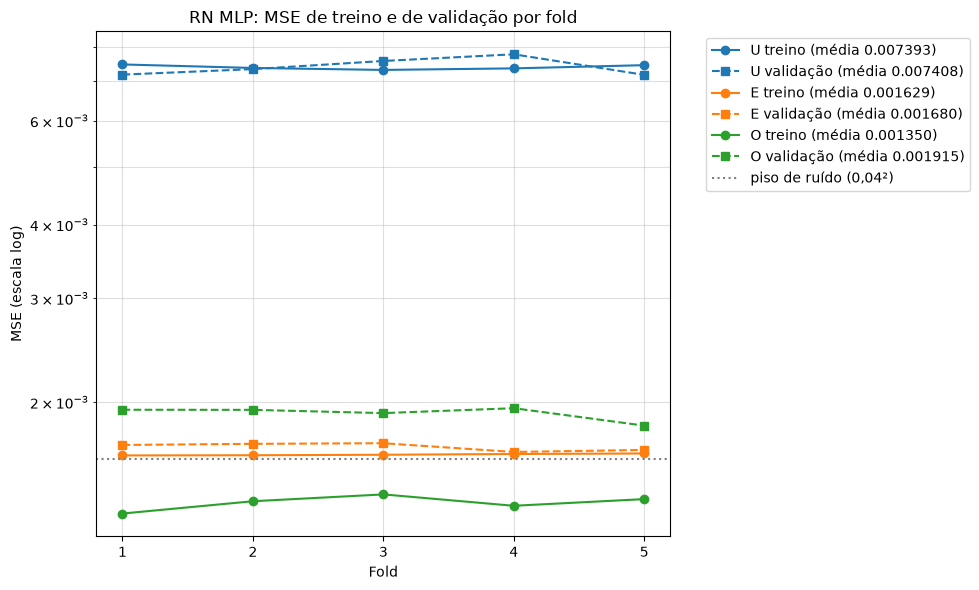

In [6]:
CORES = {'U': 'tab:blue', 'E': 'tab:orange', 'O': 'tab:green'}
folds = np.arange(1, K_FOLDS + 1)

plt.figure(figsize=(10, 6))
for rotulo in ROTULOS:
    plt.plot(folds, mse_treino[rotulo], marker='o', color=CORES[rotulo],
             label=f"{rotulo} treino (média {resumo[rotulo]['mse_treino']['media']:.6f})")
    plt.plot(folds, mse_vld[rotulo], marker='s', linestyle='--', color=CORES[rotulo],
             label=f"{rotulo} validação (média {resumo[rotulo]['mse_validacao']['media']:.6f})")
plt.axhline(0.04 ** 2, color='gray', linestyle=':', label='piso de ruído (0,04²)')

plt.yscale('log')
plt.xlabel("Fold")
plt.ylabel("MSE (escala log)")
plt.title("RN MLP: MSE de treino e de validação por fold")
plt.xticks(folds)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(which='both', alpha=0.4)
plt.tight_layout()
plt.show()

**(6) Critério de U/E/O e melhor modelo**

Critério de **melhor modelo** (spec, issue #1), o mesmo do CART:
1. menor MSE médio de validação;
2. **empate técnico**: hiperparametrizações com MSE médio de validação dentro de 5% do menor valor;
3. entre as empatadas, desempate pelo menor dpa de validação e, depois, pela menor média das difs.

E verificamos o critério de U/E/O: U tem o maior MSE médio de validação dos três (com treino ≈ validação), O tem a maior média das difs (treino claramente abaixo da validação) e o critério de melhor modelo escolhe E.

In [7]:
TOLERANCIA_EMPATE = 0.05  # empate técnico: até 5% acima do menor MSE médio de validação

def melhor_modelo(resumo, tolerancia=TOLERANCIA_EMPATE):
    menor_vld = min(r['mse_validacao']['media'] for r in resumo.values())
    limite = menor_vld * (1 + tolerancia)
    empatados = [rot for rot, r in resumo.items() if r['mse_validacao']['media'] <= limite]
    # Desempate: menor dpa de validação, depois menor média das difs
    melhor = min(empatados, key=lambda rot: (resumo[rot]['mse_validacao']['dpa'], resumo[rot]['difs']['media']))
    return melhor, empatados, limite

melhor, empatados, limite_empate = melhor_modelo(resumo)

print(f"Menor MSE médio de validação.:\t{limite_empate / (1 + TOLERANCIA_EMPATE):.6f}")
print(f"Limite do empate técnico (5%):\t{limite_empate:.6f}")
print(f"Empatados....................:\t{empatados}")
print(f"Melhor modelo................:\t{melhor} ({NOMES[melhor]}) {HIPERPARAMETRIZACOES[melhor]}")

# Critério de U/E/O
maior_vld = max(ROTULOS, key=lambda rot: resumo[rot]['mse_validacao']['media'])
maior_dif = max(ROTULOS, key=lambda rot: resumo[rot]['difs']['media'])
print(f"Maior MSE médio de validação.:\t{maior_vld}")
print(f"Maior média das difs.........:\t{maior_dif}")

assert maior_vld == 'U', f"U deveria ter o maior MSE médio de validação, mas foi {maior_vld}"
assert maior_dif == 'O', f"O deveria ter a maior média das difs, mas foi {maior_dif}"
assert melhor == 'E', f"o critério de melhor modelo deveria escolher E, mas escolheu {melhor}"
# O: treino claramente abaixo da validação
assert resumo['O']['mse_treino']['media'] < resumo['O']['mse_validacao']['media']

Menor MSE médio de validação.:	0.001680
Limite do empate técnico (5%):	0.001764
Empatados....................:	['E']
Melhor modelo................:	E (Equilibrada) {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.02, 'alpha': 0.01, 'batch_size': 'auto', 'max_iter': 2000, 'tol': 1e-06, 'n_iter_no_change': 20}
Maior MSE médio de validação.:	U
Maior média das difs.........:	O


**(7) Gravação em `results/rn.json`**

Este JSON é lido pelo `04_teste_cego.ipynb` para montar as tabelas 4 e 5 do relatório e para retreinar o melhor modelo com as 10.000 vítimas (`hiperparametrizacoes[melhor]` tem todos os parâmetros do `MLPRegressor`).

In [8]:
resultado = {
    'algoritmo': 'RN MLP (StandardScaler + MLPRegressor)',
    'features_entrada': FEATURES_ENTRADA,
    'alvo': ALVO,
    'validacao_cruzada': {
        'k_folds': K_FOLDS,
        'shuffle': True,
        'random_state': RANDOM_STATE,
        'scoring': 'neg_mean_squared_error',
        'pipeline': ['StandardScaler', 'MLPRegressor'],
    },
    # Tabela 4
    'hiperparametrizacoes': {
        rotulo: {
            'nome': NOMES[rotulo],
            'hidden_layer_sizes': list(hp['hidden_layer_sizes']),
            'n_camadas_ocultas': len(hp['hidden_layer_sizes']),
            **BASE,
            **{k: v for k, v in hp.items() if k != 'hidden_layer_sizes'},
        }
        for rotulo, hp in HIPERPARAMETRIZACOES.items()
    },
    # Tabela 5
    'resultados': {
        rotulo: {
            'mse_treino_folds': mse_treino[rotulo].tolist(),
            'mse_validacao_folds': mse_vld[rotulo].tolist(),
            'difs_folds': difs[rotulo].tolist(),
            **resumo[rotulo],
            'epocas_folds': epocas[rotulo],
            'tempo_cv_s': tempo[rotulo],
        }
        for rotulo in ROTULOS
    },
    'criterio_melhor': {
        'tolerancia_empate': TOLERANCIA_EMPATE,
        'limite_empate': limite_empate,
        'empatados': empatados,
    },
    'melhor': melhor,
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)
    f.write('\n')

# Confere o que foi gravado
with open(RESULTS_JSON, encoding='utf-8') as f:
    relido = json.load(f)
assert relido['melhor'] == 'E'
assert set(relido['hiperparametrizacoes']) == set(relido['resultados']) == {'U', 'E', 'O'}
assert all(len(r['mse_validacao_folds']) == K_FOLDS for r in relido['resultados'].values())
assert not set(FEATURES_PROIBIDAS) & set(relido['features_entrada'])

print(RESULTS_JSON.read_text(encoding='utf-8'))

{
  "algoritmo": "RN MLP (StandardScaler + MLPRegressor)",
  "features_entrada": [
    "idade",
    "fc",
    "fr",
    "pas",
    "spo2",
    "temp",
    "pr",
    "sg",
    "fx",
    "queim"
  ],
  "alvo": "sobr",
  "validacao_cruzada": {
    "k_folds": 5,
    "shuffle": true,
    "random_state": 42,
    "scoring": "neg_mean_squared_error",
    "pipeline": [
      "StandardScaler",
      "MLPRegressor"
    ]
  },
  "hiperparametrizacoes": {
    "U": {
      "nome": "Subajustada",
      "hidden_layer_sizes": [
        2
      ],
      "n_camadas_ocultas": 1,
      "solver": "sgd",
      "activation": "tanh",
      "momentum": 0.95,
      "learning_rate": "constant",
      "shuffle": true,
      "random_state": 42,
      "learning_rate_init": 0.001,
      "alpha": 1.0,
      "batch_size": "auto",
      "max_iter": 200,
      "tol": 0.0001,
      "n_iter_no_change": 10
    },
    "E": {
      "nome": "Equilibrada",
      "hidden_layer_sizes": [
        64,
        32
      ],
      "n_c